1) find threhsold
2) check how many in test set are to be edited if applying threshold
3) save final test set for each task that need to be edited after applying threshold (i.e. energy model class proba is lower than threshold)

In [3]:
import os
os.chdir('/data/hyeryung/mucoco')
import argparse
import math
import json

import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score
import seaborn as sns
import numpy as np
from transformers import AutoTokenizer, AutoConfig
import transformers


import new_module.losses as lossbuilder
from new_module.utils.robertacustom import RobertaCustomForSequenceClassification
from new_module.em_training.analyze_model import predict_labels

def bin_labels(x):
    if 0 <= x < 0.1:
        return 0
    elif 0.1 <= x < 0.2:
        return 1
    elif 0.2 <= x < 0.3:
        return 2
    elif 0.3 <= x < 0.4:
        return 3
    elif 0.4 <= x < 0.5:
        return 4
    elif 0.5 <= x < 0.6:
        return 5
    elif 0.6 <= x < 0.7:
        return 6
    elif 0.7 <= x < 0.8:
        return 7
    elif 0.8 <= x < 0.9:
        return 8
    elif 0.9 <= x <= 1.0:
        return 9
    
def bin_labels_nli(x):
    if x == 0:
        return 0
    elif 0 < x < 0.5:
        return 1
    elif 0.5 <= x < 1.0:
        return 2
    elif x==1.0:
        return 3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Finding threshold

## toxicity, energy

In [ ]:
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint',
    test_data_path='/data/hyeryung/loc_edit/data/toxicity/jigsaw-unintended-bias-in-toxicity-classification/fine-grained/valid.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint',
    batch_size=32,
    model_type='roberta-base'
)
label_predictions = predict_labels(args,device)
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


In [19]:
label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.051385
0.20    0.153811
0.25    0.212688
0.30    0.278912
0.40    0.420506
0.50    0.584498
0.60    0.754991
0.70    0.877541
0.75    0.911311
0.80    0.932461
0.90    0.962967
1.00    0.996601
Name: predictions, dtype: float64

In [ ]:
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")

acc: 0.8270
auroc: 0.9199


In [ ]:
print(f"Proportion of label 0: {(label_predictions['labels'] <= 0.5).sum() / len(label_predictions['labels'])}")
print(label_predictions['predictions'].quantile(0.5))

Proportion of label 0: 0.5027932960893855
0.584498405456543


### plots

Text(0.5, 1.0, 'Energy Model Predictions Sorted by Value (toxicity)')

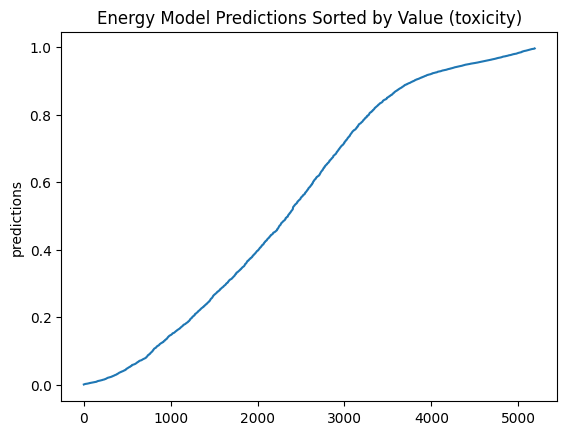

In [ ]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Energy Model Predictions Sorted by Value (toxicity)')

<Axes: xlabel='labels', ylabel='predictions'>

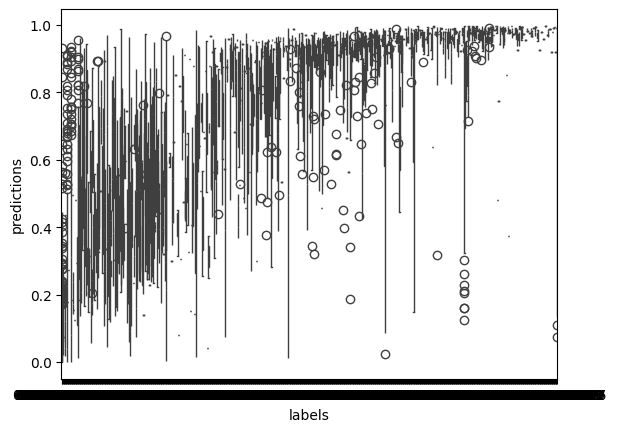

In [ ]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

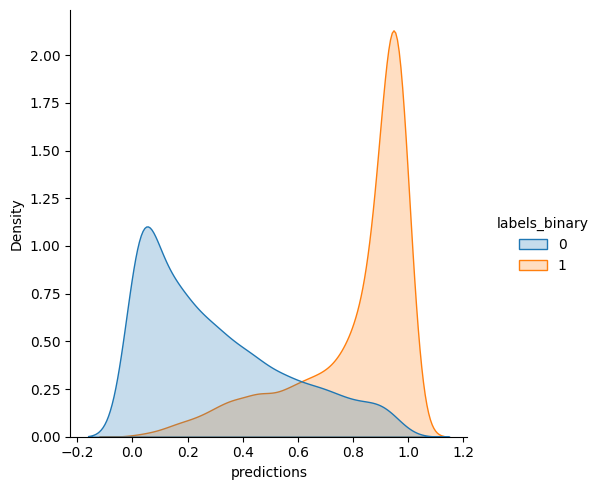

In [ ]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

### balanced valid set

In [128]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint/labels_predictions.csv', index_col=0)

In [ ]:
label_predictions['labels'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]) ## already balanced!

0.10    0.111111
0.20    0.200000
0.25    0.300000
0.30    0.333333
0.40    0.400000
0.50    0.500000
0.60    0.700000
0.70    0.764706
0.75    0.800000
0.80    0.848101
0.90    0.957447
1.00    1.000000
Name: labels, dtype: float64

### nontoxicity threshold

In [21]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint/labels_predictions.csv', index_col=0)

In [22]:
label_predictions['predictions'] = 1 - label_predictions['predictions']

In [23]:
label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]) ## already balanced!

0.10    0.037033
0.20    0.067539
0.25    0.088689
0.30    0.122459
0.40    0.245009
0.50    0.415502
0.60    0.579494
0.70    0.721088
0.75    0.787312
0.80    0.846189
0.90    0.948615
1.00    0.999540
Name: predictions, dtype: float64

## toxicity, classifier

In [ ]:
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-with-gpt2-large-embeds-2/step_2600_best_checkpoint/',
    test_data_path='/data/hyeryung/loc_edit/data/toxicity/jigsaw-unintended-bias-in-toxicity-classification/fine-grained/valid.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-with-gpt2-large-embeds-2/step_2600_best_checkpoint/',
    batch_size=32,
    model_type='roberta-base-custom'
)

label_predictions = predict_labels(args,device)
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


50265


In [21]:
label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.005478
0.20    0.035349
0.25    0.066514
0.30    0.126741
0.40    0.333116
0.50    0.624835
0.60    0.880091
0.70    0.987265
0.75    0.996154
0.80    0.998923
0.90    0.999896
1.00    0.999940
Name: predictions, dtype: float64

In [ ]:
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")

acc: 0.8154
auroc: 0.9055


### nontoxicity threshold

In [51]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-with-gpt2-large-embeds-2/step_2600_best_checkpoint/labels_predictions.csv', index_col=0)

In [52]:
label_predictions['predictions'] = 1 - label_predictions['predictions']

In [53]:
label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]) ## already balanced!

0.10    0.000104
0.20    0.001077
0.25    0.003846
0.30    0.012735
0.40    0.119909
0.50    0.375165
0.60    0.666884
0.70    0.873259
0.75    0.933486
0.80    0.964651
0.90    0.994522
1.00    0.999640
Name: predictions, dtype: float64

## toxicity, classifier (no embed share)

In [ ]:
## share embeds 하지 않는 모델의 성능만 quick 하게 체크 
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier/step_500_best_checkpoint/',
    test_data_path='/data/hyeryung/loc_edit/data/toxicity/jigsaw-unintended-bias-in-toxicity-classification/fine-grained/valid.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier/step_500_best_checkpoint/',
    batch_size=32,
    model_type='roberta-base',
    task=''
)

label_predictions = predict_labels(args,device)
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


0.10    0.001329
0.20    0.005256
0.25    0.012056
0.30    0.028299
0.40    0.163409
0.50    0.572983
0.60    0.932381
0.70    0.994712
0.75    0.998794
0.80    0.999664
0.90    0.999923
1.00    0.999959
Name: predictions, dtype: float64
acc: 0.8330
auroc: 0.9124


In [ ]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier/step_500_best_checkpoint/labels_predictions.csv', index_col=0)
label_predictions['predictions'] = 1 - label_predictions['predictions']
label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]) ## already balanced!

0.10    0.000077
0.20    0.000336
0.25    0.001206
0.30    0.005288
0.40    0.067619
0.50    0.427017
0.60    0.836591
0.70    0.971701
0.75    0.987944
0.80    0.994744
0.90    0.998671
1.00    0.999661
Name: predictions, dtype: float64

## toxicity, classifier (gemma2 embed share)

In [ ]:
## share embeds 하지 않는 모델의 성능만 quick 하게 체크 
ckpt_dir = '/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-with-gemma2-embeds/step_1100_best_checkpoint/'
args = argparse.Namespace(
    checkpoint_dir=ckpt_dir,
    test_data_path='/data/hyeryung/loc_edit/data/toxicity/jigsaw-unintended-bias-in-toxicity-classification/fine-grained/valid.jsonl',
    test_data_type='jsonl',
    output_dir=ckpt_dir,
    batch_size=32,
    model_type='roberta-base-custom',
    task=''
)

label_predictions = predict_labels(args,device)
# print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")

label_predictions['predictions'] = 1 - label_predictions['predictions']
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])) ## already balanced!

50265
acc: 0.8187
auroc: 0.9103
0.10    0.000030
0.20    0.000791
0.25    0.003012
0.30    0.012468
0.40    0.087906
0.50    0.383381
0.60    0.806363
0.70    0.971733
0.75    0.993140
0.80    0.999017
0.90    0.999913
1.00    0.999947
Name: predictions, dtype: float64


## formality, energy

In [ ]:
# formality, energy model
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/',
    test_data_path='/data/hyeryung/loc_edit/data/formality/PT16/valid.tsv',
    test_data_type='tsv',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/',
    batch_size=32,
    model_type='roberta-base'
)

label_predictions = predict_labels(args,device)
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


0.10    0.016616
0.20    0.058802
0.25    0.091474
0.30    0.117134
0.40    0.257464
0.50    0.364168
0.60    0.461556
0.70    0.539999
0.75    0.586064
0.80    0.640245
0.90    0.794336
1.00    0.985254
Name: predictions, dtype: float64
acc: 0.8431
auroc: 0.9090


In [ ]:
prop_75 = (label_predictions['labels'] <= 0.75).sum() / len(label_predictions['labels'])
print(f"Proportion of label 0: {prop_75}")
print(label_predictions['predictions'].quantile(prop_75))

Proportion of label 0: 0.9255533199195171
0.849987830194669


### plots

Text(0.5, 1.0, 'Energy Model Predictions Sorted by Value (formality)')

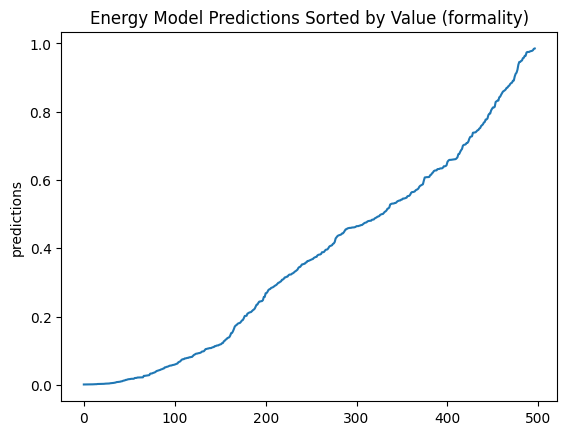

In [116]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Energy Model Predictions Sorted by Value (formality)')

<Axes: xlabel='labels', ylabel='predictions'>

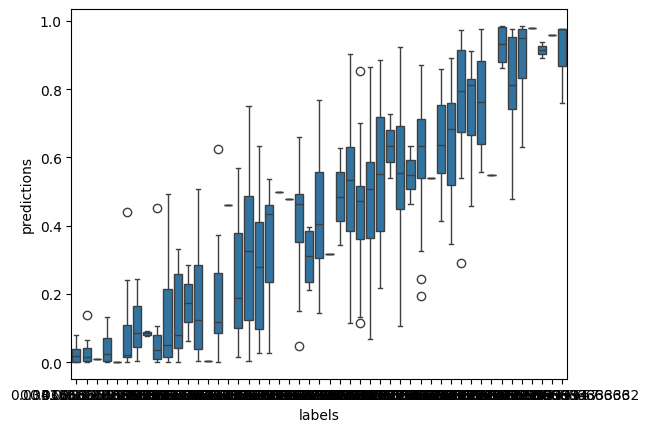

In [104]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

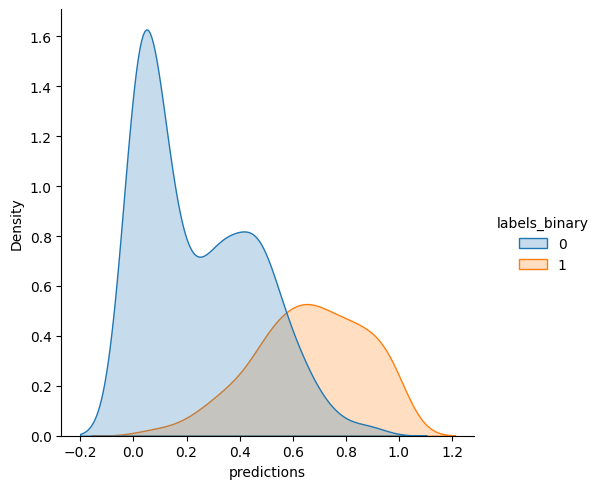

In [107]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

### balanced valid set

In [ ]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/labels_predictions.csv', index_col=0)

In [ ]:
label_predictions['labels'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.100000
0.20    0.166667
0.25    0.208333
0.30    0.233333
0.40    0.300000
0.50    0.366667
0.60    0.452778
0.70    0.533333
0.75    0.566667
0.80    0.600000
0.90    0.700000
1.00    0.933333
Name: labels, dtype: float64

In [ ]:


label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels)

In [ ]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
0    40
1    84
2    56
3    91
4    51
5    65
6    54
7    37
8    13
9     6
Name: count, dtype: int64

In [ ]:
balanced_label_predictions = label_predictions.loc[label_predictions['labels_bins'] < 9,:].groupby('labels_bins').sample(13,random_state=999)#.drop_duplicates()
balanced_label_predictions = pd.concat([balanced_label_predictions, label_predictions.loc[label_predictions['labels_bins'] == 9,:]])
print(balanced_label_predictions.shape)

(123, 3)


In [ ]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.027309
0.20    0.092905
0.25    0.116525
0.30    0.151714
0.40    0.284894
0.50    0.461653
0.60    0.545315
0.70    0.650393
0.75    0.739051
0.80    0.808901
0.90    0.933145
1.00    0.985254
Name: predictions, dtype: float64

In [ ]:
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")


acc: 0.8537
auroc: 0.9318


### informality threshold

In [29]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/labels_predictions.csv', index_col=0)

In [30]:
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels)

In [31]:
balanced_label_predictions = label_predictions.loc[label_predictions['labels_bins'] < 9,:].groupby('labels_bins').sample(13,random_state=999)#.drop_duplicates()
balanced_label_predictions = pd.concat([balanced_label_predictions, label_predictions.loc[label_predictions['labels_bins'] == 9,:]])
print(balanced_label_predictions.shape)

(123, 3)


In [32]:
balanced_label_predictions['predictions'] = 1 - balanced_label_predictions['predictions']

In [33]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.066855
0.20    0.191099
0.25    0.260949
0.30    0.349607
0.40    0.454685
0.50    0.538347
0.60    0.715106
0.70    0.848286
0.75    0.883475
0.80    0.907095
0.90    0.972691
1.00    0.998873
Name: predictions, dtype: float64

## formality, classifier

In [ ]:
# formality, classifier
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-with-gpt2-large-embeds/step_1116_best_checkpoint/',
    test_data_path='/data/hyeryung/loc_edit/data/formality/PT16/valid.tsv',
    test_data_type='tsv',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-with-gpt2-large-embeds/step_1116_best_checkpoint/',
    batch_size=32,
    model_type='roberta-base-custom'
)

label_predictions = predict_labels(args,device)
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


50265
0.10    0.000124
0.20    0.000126
0.25    0.000128
0.30    0.000129
0.40    0.000134
0.50    0.000216
0.60    0.002563
0.70    0.034903
0.75    0.231531
0.80    0.415012
0.90    0.773593
1.00    0.991355
Name: predictions, dtype: float64
acc: 0.7968
auroc: 0.8404


In [ ]:
print(f"Proportion of label 0: {(label_predictions['labels'] <= 0.5).sum() / len(label_predictions['labels'])}")
print(label_predictions['predictions'].quantile(0.69))

Proportion of label 0: 0.6881287726358148
0.025518970564007648


### plots

Text(0.5, 1.0, 'Classifier Model Predictions Sorted by Value (formality)')

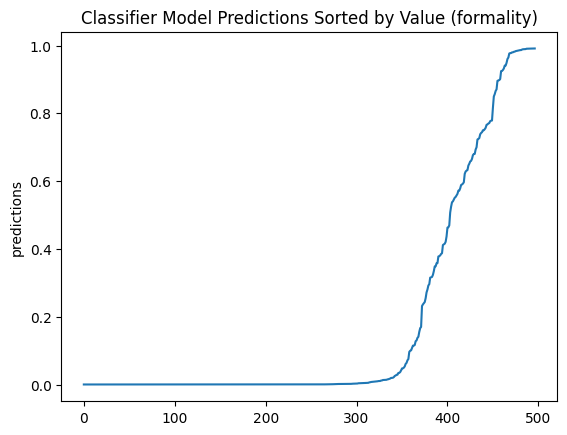

In [113]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Classifier Model Predictions Sorted by Value (formality)')

<Axes: xlabel='labels', ylabel='predictions'>

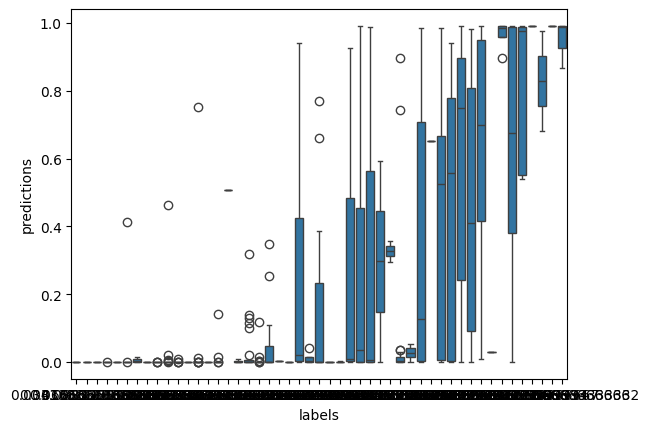

In [111]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

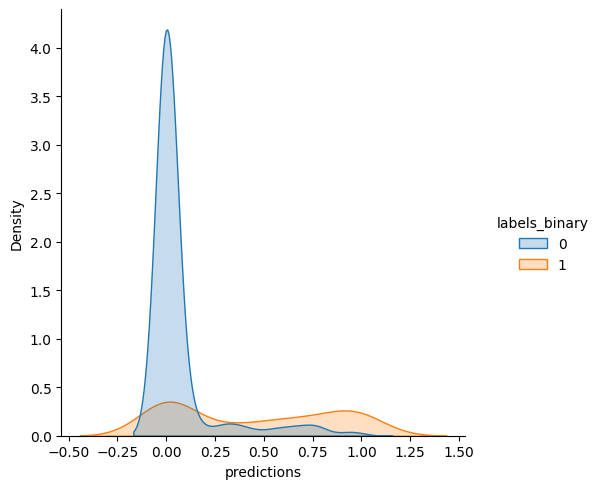

In [112]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

### balanced valid set

In [ ]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-with-gpt2-large-embeds/step_1116_best_checkpoint/labels_predictions.csv', index_col=0)

In [ ]:
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels)

In [ ]:
balanced_label_predictions = label_predictions.loc[label_predictions['labels_bins'] < 9,:].groupby('labels_bins').sample(13,random_state=999)#.drop_duplicates()
balanced_label_predictions = pd.concat([balanced_label_predictions, label_predictions.loc[label_predictions['labels_bins'] == 9,:]])
print(balanced_label_predictions.shape)

(123, 3)


In [ ]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.000125
0.20    0.000127
0.25    0.000129
0.30    0.000132
0.40    0.000143
0.50    0.001439
0.60    0.032399
0.70    0.438131
0.75    0.596801
0.80    0.729961
0.90    0.979568
1.00    0.991355
Name: predictions, dtype: float64

In [ ]:
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")


acc: 0.7642
auroc: 0.8725


### informality threshold

In [46]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-with-gpt2-large-embeds/step_1116_best_checkpoint/labels_predictions.csv', index_col=0)

In [47]:
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels)

In [48]:
balanced_label_predictions = label_predictions.loc[label_predictions['labels_bins'] < 9,:].groupby('labels_bins').sample(13,random_state=999)#.drop_duplicates()
balanced_label_predictions = pd.concat([balanced_label_predictions, label_predictions.loc[label_predictions['labels_bins'] == 9,:]])
print(balanced_label_predictions.shape)

(123, 3)


In [49]:
balanced_label_predictions['predictions'] = 1 - balanced_label_predictions['predictions']

In [50]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.020432
0.20    0.270039
0.25    0.403199
0.30    0.561869
0.40    0.967601
0.50    0.998561
0.60    0.999857
0.70    0.999868
0.75    0.999871
0.80    0.999873
0.90    0.999875
1.00    0.999880
Name: predictions, dtype: float64

## formality, classifier (no embed share)

In [ ]:
## share embeds 하지 않는 모델의 성능만 quick 하게 확인
# formality, classifier
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier/step_558_best_checkpoint/',
    test_data_path='/data/hyeryung/loc_edit/data/formality/PT16/valid.tsv',
    test_data_type='tsv',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier/step_558_best_checkpoint/',
    batch_size=32,
    model_type='roberta-base',
    task=''
)

label_predictions = predict_labels(args,device)
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


0.10    0.000269
0.20    0.000305
0.25    0.000374
0.30    0.000475
0.40    0.001921
0.50    0.016637
0.60    0.099182
0.70    0.301228
0.75    0.438356
0.80    0.590728
0.90    0.809292
1.00    0.974873
Name: predictions, dtype: float64
acc: 0.8451
auroc: 0.8931


In [ ]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier/step_558_best_checkpoint/labels_predictions.csv', index_col=0)
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels)
balanced_label_predictions = label_predictions.loc[label_predictions['labels_bins'] < 9,:].groupby('labels_bins').sample(13,random_state=999)#.drop_duplicates()
balanced_label_predictions = pd.concat([balanced_label_predictions, label_predictions.loc[label_predictions['labels_bins'] == 9,:]])
print(balanced_label_predictions.shape)
print(balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")

(123, 3)
0.10    0.000283
0.20    0.000375
0.25    0.000458
0.30    0.001023
0.40    0.004407
0.50    0.027776
0.60    0.190544
0.70    0.551816
0.75    0.704521
0.80    0.805901
0.90    0.883300
1.00    0.974873
Name: predictions, dtype: float64
acc: 0.8211
auroc: 0.9101


In [ ]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier/step_558_best_checkpoint/labels_predictions.csv', index_col=0)
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels)
balanced_label_predictions = label_predictions.loc[label_predictions['labels_bins'] < 9,:].groupby('labels_bins').sample(13,random_state=999)#.drop_duplicates()
balanced_label_predictions = pd.concat([balanced_label_predictions, label_predictions.loc[label_predictions['labels_bins'] == 9,:]])
print(balanced_label_predictions.shape)
balanced_label_predictions['predictions'] = 1 - balanced_label_predictions['predictions']
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

(123, 3)


0.10    0.116700
0.20    0.194099
0.25    0.295479
0.30    0.448184
0.40    0.809456
0.50    0.972224
0.60    0.995593
0.70    0.998977
0.75    0.999542
0.80    0.999625
0.90    0.999717
1.00    0.999768
Name: predictions, dtype: float64

## formality, classifier (gemma2 embed share)

In [ ]:
# formality, classifier
ckpt_dir = '/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-with-gemma2-embeds/step_144_best_checkpoint/'
args = argparse.Namespace(
    checkpoint_dir=ckpt_dir,
    test_data_path='/data/hyeryung/loc_edit/data/formality/PT16/valid.tsv',
    test_data_type='tsv',
    output_dir=ckpt_dir,
    batch_size=32,
    model_type='roberta-base-custom',
    task=''
)

label_predictions = predict_labels(args,device)
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")

print('------ balanced val set result ------')
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels)
balanced_label_predictions = label_predictions.loc[label_predictions['labels_bins'] < 9,:].groupby('labels_bins').sample(13,random_state=999)#.drop_duplicates()
balanced_label_predictions = pd.concat([balanced_label_predictions, label_predictions.loc[label_predictions['labels_bins'] == 9,:]])
print(balanced_label_predictions.shape)
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")

print('------ balanced val set quantile (class 1) ------')
print(balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))

print('------ balanced val set quantile (class 0) ------')
balanced_label_predictions['predictions'] = 1 - balanced_label_predictions['predictions']
print(balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))

50265
0.10    0.000099
0.20    0.000108
0.25    0.000120
0.30    0.000158
0.40    0.000695
0.50    0.015255
0.60    0.186122
0.70    0.723730
0.75    0.880274
0.80    0.981330
0.90    0.999599
1.00    0.999682
Name: predictions, dtype: float64
acc: 0.7948
auroc: 0.8752
------ balanced val set result ------
(123, 3)
acc: 0.7886
auroc: 0.8873
------ balanced val set quantile (class 1) ------
0.10    0.000101
0.20    0.000109
0.25    0.000135
0.30    0.000220
0.40    0.001328
0.50    0.088501
0.60    0.680743
0.70    0.883825
0.75    0.984211
0.80    0.999375
0.90    0.999622
1.00    0.999679
Name: predictions, dtype: float64
------ balanced val set quantile (class 0) ------
0.10    0.000378
0.20    0.000625
0.25    0.015789
0.30    0.116175
0.40    0.319257
0.50    0.911499
0.60    0.998672
0.70    0.999780
0.75    0.999865
0.80    0.999891
0.90    0.999899
1.00    0.999904
Name: predictions, dtype: float64


## sentiment, energy

In [90]:
# sentiment, energy model
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint',
    test_data_path='/data/hyeryung/loc_edit/data/yelp/valid.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint',
    batch_size=32,
    model_type='roberta-base'
)

label_predictions = predict_labels(args,device)
if label_predictions['labels'].max() > 1:
    label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


0.10    0.002777
0.20    0.174225
0.25    0.390087
0.30    0.573905
0.40    0.887451
0.50    0.965995
0.60    0.991556
0.70    0.998068
0.75    0.999145
0.80    0.999699
0.90    0.999976
1.00    0.999999
Name: predictions, dtype: float64
acc: 0.9464
auroc: 0.9892


In [97]:
print(f"Proportion of label 0: {(label_predictions['labels'] <= 0.5).sum() / len(label_predictions['labels'])}")
print(label_predictions['predictions'].quantile(0.33))

Proportion of label 0: 0.3298
0.7386573630571366


In [ ]:
prop_75 = (label_predictions['labels'] <= 0.75).sum() / len(label_predictions['labels'])
print(f"Proportion of label 0: {prop_75}")
print(label_predictions['predictions'].quantile(prop_75))

Proportion of label 0: 0.9255533199195171
0.849987830194669


### plots

Text(0.5, 1.0, 'Energy Model Predictions Sorted by Value (sentiment)')

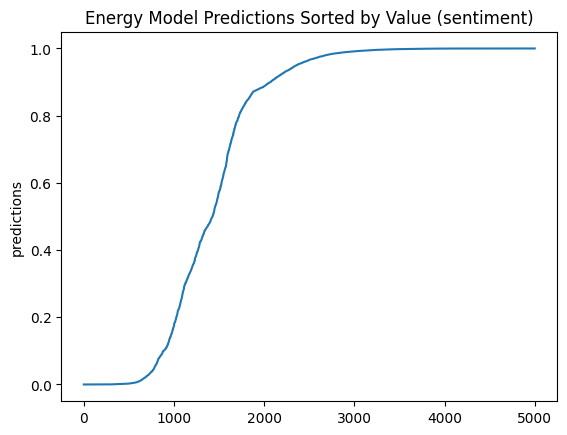

In [ ]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Energy Model Predictions Sorted by Value (sentiment)')

<Axes: xlabel='labels', ylabel='predictions'>

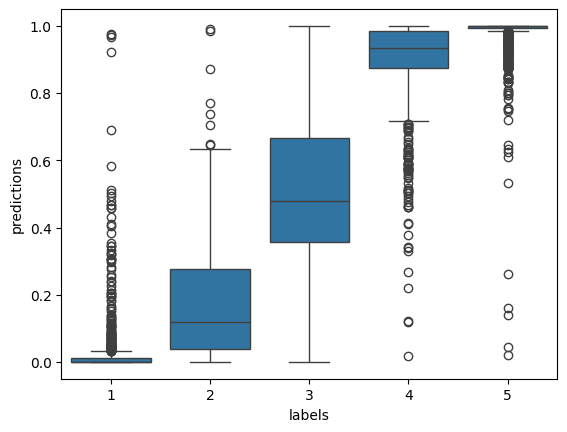

In [ ]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

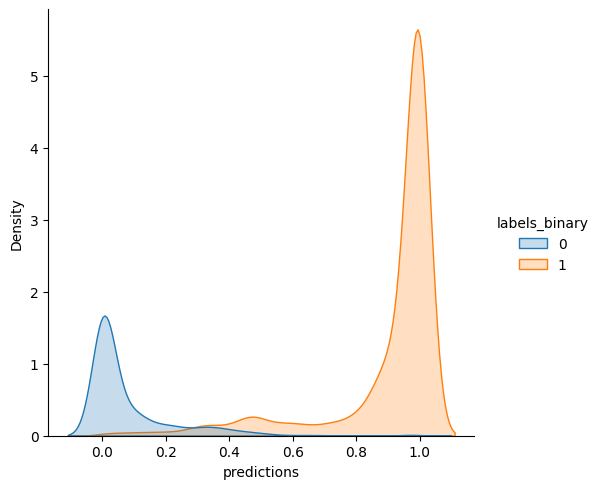

In [ ]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

### balanced valid set

In [195]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint/labels_predictions.csv', index_col=0)

In [196]:
label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )

In [169]:
label_predictions['labels'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.00
0.20    0.25
0.25    0.50
0.30    0.50
0.40    0.75
0.50    0.75
0.60    1.00
0.70    1.00
0.75    1.00
0.80    1.00
0.90    1.00
1.00    1.00
Name: labels, dtype: float64

In [197]:
label_predictions['labels_bins'] = label_predictions['labels']#.apply(bin_labels)

In [171]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
0.00     765
0.25     389
0.50     495
0.75    1039
1.00    2312
Name: count, dtype: int64

In [198]:
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(389, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)

(1945, 3)


In [175]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.001023
0.20    0.026121
0.25    0.078115
0.30    0.132620
0.40    0.328918
0.50    0.500150
0.60    0.809421
0.70    0.927162
0.75    0.970762
0.80    0.990170
0.90    0.999563
1.00    0.999999
Name: predictions, dtype: float64

In [199]:
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")


acc: 0.8936
auroc: 0.9834


### negativity threshold

In [34]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint/labels_predictions.csv', index_col=0)

In [35]:
label_predictions['labels_bins'] = label_predictions['labels']#.apply(bin_labels)

In [36]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
1     765
2     389
3     495
4    1039
5    2312
Name: count, dtype: int64

In [37]:
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(389, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)

(1945, 3)


In [38]:
balanced_label_predictions['predictions'] = 1- balanced_label_predictions['predictions']

In [39]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.000437
0.20    0.009830
0.25    0.029238
0.30    0.072838
0.40    0.190579
0.50    0.499850
0.60    0.671082
0.70    0.867380
0.75    0.921885
0.80    0.973879
0.90    0.998977
1.00    0.999998
Name: predictions, dtype: float64

## sentiment, classifier

In [ ]:
# sentiment, classifier model
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-with-gpt2-large-embeds/step_114500_best_checkpoint',
    test_data_path='/data/hyeryung/loc_edit/data/yelp/valid.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-with-gpt2-large-embeds/step_114500_best_checkpoint',
    batch_size=32,
    model_type='roberta-base-custom'
)

label_predictions = predict_labels(args,device)
if label_predictions['labels'].max() > 1:
    label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


50265
0.10    8.622667e-07
0.20    1.429650e-04
0.25    1.669537e-02
0.30    9.381881e-01
0.40    9.999993e-01
0.50    1.000000e+00
0.60    1.000000e+00
0.70    1.000000e+00
0.75    1.000000e+00
0.80    1.000000e+00
0.90    1.000000e+00
1.00    1.000000e+00
Name: predictions, dtype: float64
acc: 0.9420
auroc: 0.9815


In [99]:
print(f"Proportion of label 0: {(label_predictions['labels'] <= 0.5).sum() / len(label_predictions['labels'])}")
print(label_predictions['predictions'].quantile(0.33))

Proportion of label 0: 0.3298
0.9992624485492706


In [ ]:
label_predictions.groupby('labels').size().cumsum()

labels
1     765
2     389
3     495
4    1039
5    2312
dtype: int64

### plots

<Axes: xlabel='labels', ylabel='predictions'>

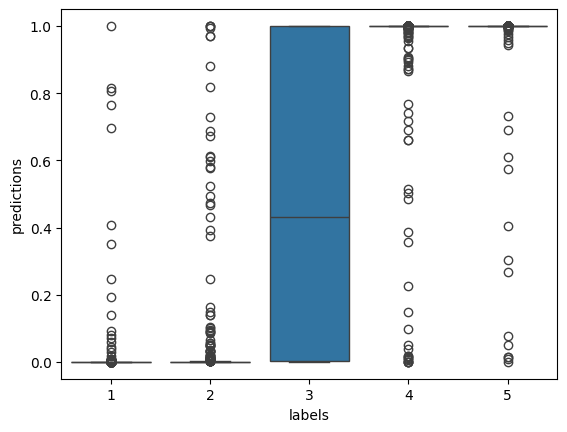

In [68]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

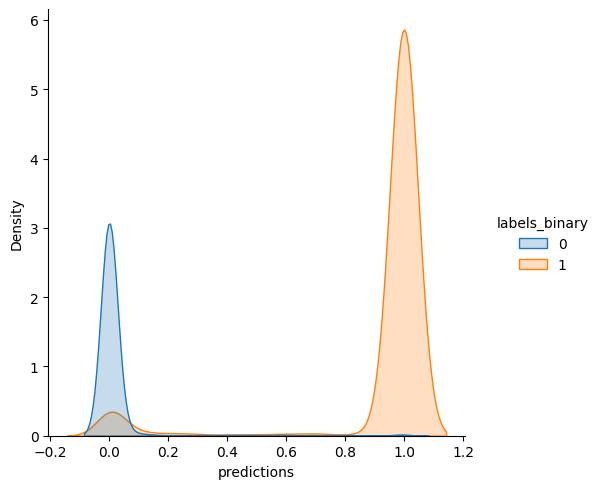

In [ ]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

Text(0.5, 1.0, 'Classifier Model Predictions Sorted by Value (sentiment)')

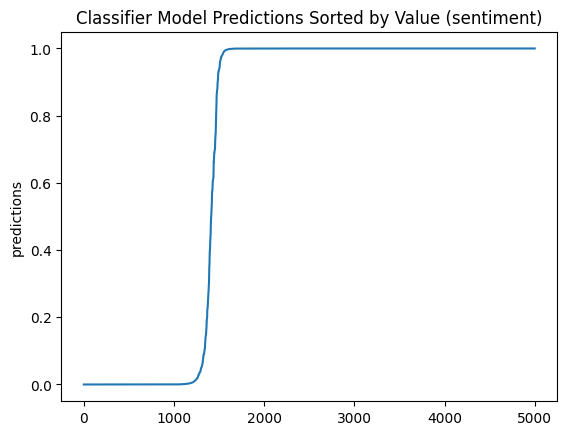

In [84]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Classifier Model Predictions Sorted by Value (sentiment)')

### balanced valid set

In [200]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-with-gpt2-large-embeds/step_114500_best_checkpoint/labels_predictions.csv', index_col=0)

In [201]:
label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )

In [202]:
label_predictions['labels'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.00
0.20    0.25
0.25    0.50
0.30    0.50
0.40    0.75
0.50    0.75
0.60    1.00
0.70    1.00
0.75    1.00
0.80    1.00
0.90    1.00
1.00    1.00
Name: labels, dtype: float64

In [203]:
label_predictions['labels_bins'] = label_predictions['labels']#.apply(bin_labels)

In [204]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
0.00     765
0.25     389
0.50     495
0.75    1039
1.00    2312
Name: count, dtype: int64

In [205]:
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(389, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)

(1945, 3)


In [206]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    3.340028e-07
0.20    2.043536e-06
0.25    6.287420e-06
0.30    4.745365e-05
0.40    2.911271e-03
0.50    6.076121e-01
0.60    9.999562e-01
0.70    1.000000e+00
0.75    1.000000e+00
0.80    1.000000e+00
0.90    1.000000e+00
1.00    1.000000e+00
Name: predictions, dtype: float64

In [207]:
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")


acc: 0.8859
auroc: 0.9766


### negativity threshold

In [40]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-with-gpt2-large-embeds/step_114500_best_checkpoint/labels_predictions.csv', index_col=0)

In [41]:
label_predictions['labels_bins'] = label_predictions['labels']#.apply(bin_labels)

In [42]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
1     765
2     389
3     495
4    1039
5    2312
Name: count, dtype: int64

In [43]:
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(389, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)

(1945, 3)


In [44]:
balanced_label_predictions['predictions'] = 1- balanced_label_predictions['predictions']

In [45]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.000000
0.20    0.000000
0.25    0.000000
0.30    0.000000
0.40    0.000044
0.50    0.392388
0.60    0.997089
0.70    0.999953
0.75    0.999994
0.80    0.999998
0.90    1.000000
1.00    1.000000
Name: predictions, dtype: float64

## sentiment, classifier (no embed share)

In [ ]:
# sentiment, classifier model
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier/step_83000',
    test_data_path='/data/hyeryung/loc_edit/data/yelp/valid.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier/step_83000',
    batch_size=32,
    model_type='roberta-base',
    task=''
)

label_predictions = predict_labels(args,device)
if label_predictions['labels'].max() > 1:
    label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


0.10    0.000001
0.20    0.000396
0.25    0.039175
0.30    0.870290
0.40    0.999952
0.50    0.999999
0.60    1.000000
0.70    1.000000
0.75    1.000000
0.80    1.000000
0.90    1.000000
1.00    1.000000
Name: predictions, dtype: float64
acc: 0.9416
auroc: 0.9854


In [ ]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier/step_83000/labels_predictions.csv', index_col=0)
# label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )
# label_predictions['labels'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])
label_predictions['labels_bins'] = label_predictions['labels']#.apply(bin_labels)
label_predictions['labels_bins'].value_counts().sort_index()
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(389, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)
print(balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")


(1945, 3)
0.10    7.269428e-07
0.20    2.500847e-06
0.25    9.466515e-06
0.30    6.476974e-05
0.40    7.387384e-03
0.50    5.515044e-01
0.60    9.994061e-01
0.70    9.999975e-01
0.75    9.999994e-01
0.80    9.999998e-01
0.90    1.000000e+00
1.00    1.000000e+00
Name: predictions, dtype: float64
acc: 0.8869
auroc: 0.9797


In [ ]:
# label_predictions['labels_bins'] = label_predictions['labels']#.apply(bin_labels)
# label_predictions['labels_bins'].value_counts().sort_index()
# balanced_label_predictions = label_predictions.groupby('labels_bins').sample(389, random_state=999)#.drop_duplicates()
# print(balanced_label_predictions.shape)
balanced_label_predictions['predictions'] = 1- balanced_label_predictions['predictions']
print(balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))

0.10    0.000000e+00
0.20    2.384186e-07
0.25    5.960464e-07
0.30    2.503395e-06
0.40    5.938530e-04
0.50    4.484956e-01
0.60    9.926126e-01
0.70    9.999352e-01
0.75    9.999905e-01
0.80    9.999975e-01
0.90    9.999993e-01
1.00    9.999997e-01
Name: predictions, dtype: float64


## nli, energy model

In [ ]:
# sentiment, classifier model
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/nli/roberta_large_snli_mnli_anli_train_dev_with_finegrained_finegrained_labels_cross_entropy_n_a/zgs9e2sr/',
    model_file_name='best_model_pearsonr.pth',
    label_id=1,
    test_data_path='/data/hyeryung/mucoco/data/nli/snli_mnli_anli_train_dev_with_finegrained.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/nli/roberta_large_snli_mnli_anli_train_dev_with_finegrained_finegrained_labels_cross_entropy_n_a/zgs9e2sr/',
    batch_size=32,
    model_type='encoder-model',
    task='nli'
)

label_predictions = predict_labels(args,device)
if label_predictions['labels'].max() > 1:
    label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


0.10    0.004293
0.20    0.143975
0.25    0.298316
0.30    0.402624
0.40    0.720756
0.50    0.910338
0.60    0.996149
0.70    0.999395
0.75    0.999647
0.80    0.999743
0.90    0.999837
1.00    0.999907
Name: predictions, dtype: float64
acc: 0.8574
auroc: 0.9249


In [ ]:
print(f"Proportion of label 0: {(label_predictions['labels'] >= 0.5).sum() / len(label_predictions['labels'])}")
print(label_predictions['predictions'].quantile(0.33))

Proportion of label 0: 0.6854393156300125
0.5781707882881165


In [ ]:
label_predictions.groupby('labels').size().cumsum()

labels
0.000000    1225
0.200000    1425
0.250000    1426
0.333333    1667
0.400000    1765
0.600000    1842
0.666667    2072
0.800000    2339
1.000000    5611
dtype: int64

### plots

<Axes: xlabel='labels', ylabel='predictions'>

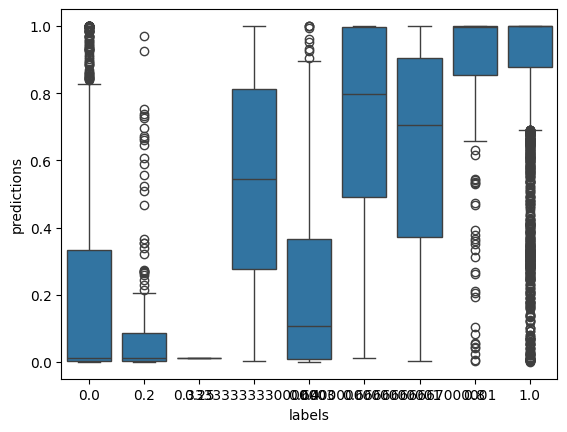

In [ ]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

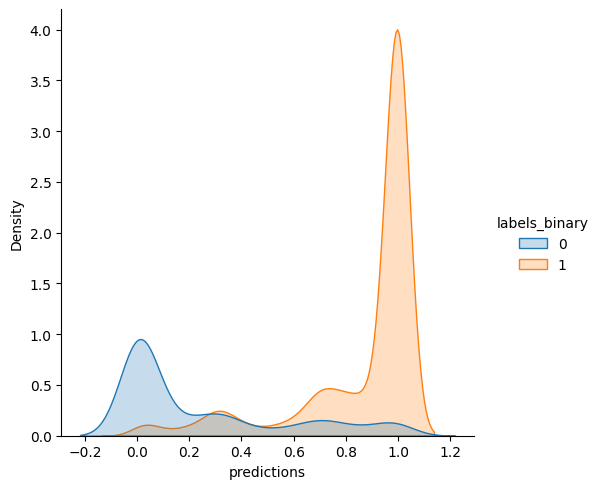

In [ ]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

Text(0.5, 1.0, 'Classifier Model Predictions Sorted by Value (logical consistency)')

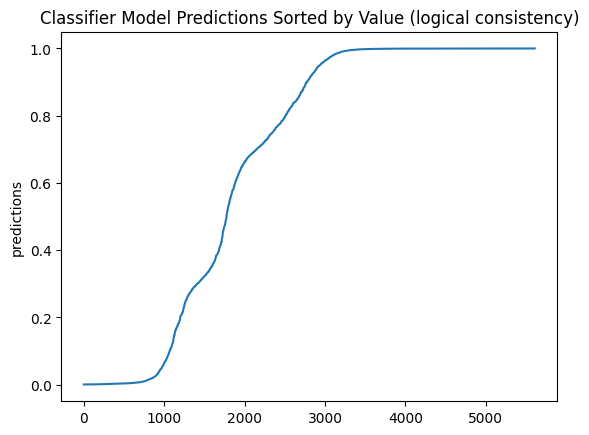

In [ ]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Classifier Model Predictions Sorted by Value (logical consistency)')

### balanced valid set

In [ ]:
label_predictions = pd.read_csv(os.path.join(args.output_dir, 'labels_predictions.csv'), index_col=0)

In [ ]:
label_predictions['labels'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.0
0.20    0.0
0.25    0.2
0.30    0.4
0.40    0.8
0.50    1.0
0.60    1.0
0.70    1.0
0.75    1.0
0.80    1.0
0.90    1.0
1.00    1.0
Name: labels, dtype: float64

In [ ]:
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels_nli)

In [ ]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
0    1225
1     540
2     574
3    3272
Name: count, dtype: int64

In [ ]:
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(540, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)

(2160, 3)


In [ ]:
balanced_label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
0    540
1    540
2    540
3    540
Name: count, dtype: int64

In [ ]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.002377
0.20    0.013802
0.25    0.049663
0.30    0.158795
0.40    0.339551
0.50    0.657591
0.60    0.801313
0.70    0.971414
0.75    0.997154
0.80    0.999202
0.90    0.999780
1.00    0.999907
Name: predictions, dtype: float64

In [ ]:
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")

acc: 0.8093
auroc: 0.8983


## nli, classifier

In [59]:
# sentiment, classifier model
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/nli/roberta_large_snli_mnli_anli_train_dev_with_finegrained_binary_labels_binary_cross_entropy_n_a/1731247443',
    model_file_name='best_model_pearsonr.pth',
    label_id=1,
    test_data_path='/data/hyeryung/mucoco/data/nli/snli_mnli_anli_train_dev_with_finegrained.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/nli/roberta_large_snli_mnli_anli_train_dev_with_finegrained_binary_labels_binary_cross_entropy_n_a/1731247443',
    batch_size=32,
    model_type='encoder-model',
    task='nli'
)

label_predictions = predict_labels(args,device)
if label_predictions['labels'].max() > 1:
    label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


0.10    0.000742
0.20    0.019074
0.25    0.071546
0.30    0.225382
0.40    0.771095
0.50    0.955440
0.60    0.988323
0.70    0.996194
0.75    0.997626
0.80    0.998374
0.90    0.999137
1.00    0.999677
Name: predictions, dtype: float64
acc: 0.8553
auroc: 0.9312


In [ ]:
print(f"Proportion of label 0: {(label_predictions['labels'] >= 0.5).sum() / len(label_predictions['labels'])}")
print(label_predictions['predictions'].quantile(0.33))

Proportion of label 0: 0.3145606843699875
0.3777983605861665


In [61]:
label_predictions.groupby('labels').size().cumsum()

labels
0.000000    1225
0.200000    1425
0.250000    1426
0.333333    1667
0.400000    1765
0.600000    1842
0.666667    2072
0.800000    2339
1.000000    5611
dtype: int64

### plots

<Axes: xlabel='labels', ylabel='predictions'>

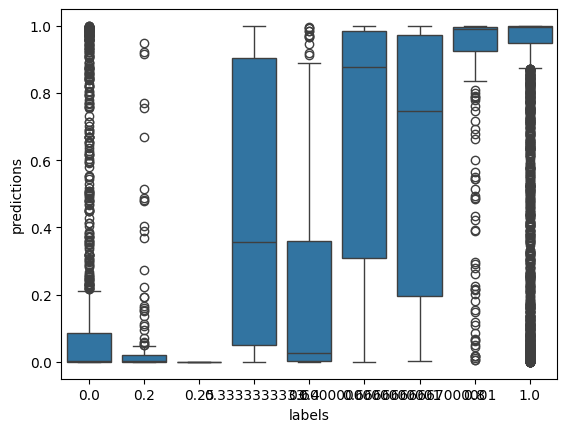

In [23]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

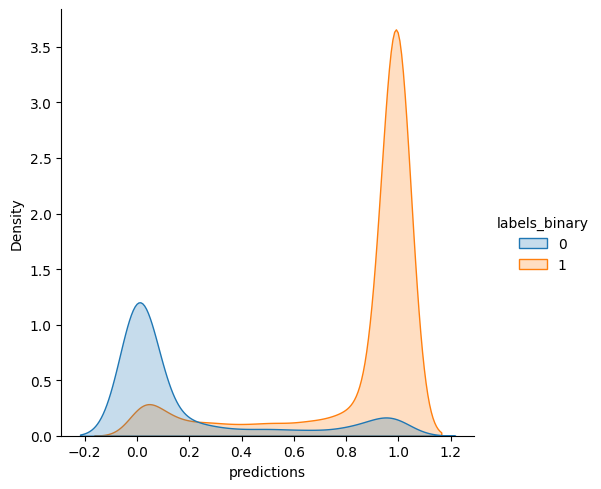

In [24]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

Text(0.5, 1.0, 'Classifier Model Predictions Sorted by Value (logical consistency)')

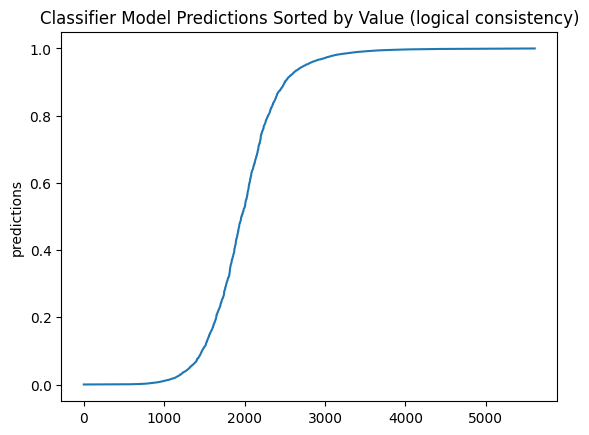

In [27]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Classifier Model Predictions Sorted by Value (logical consistency)')

### balanced valid set

In [3]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/nli/roberta_large_snli_mnli_anli_train_dev_with_finegrained_binary_labels_binary_cross_entropy_n_a/1731247443/labels_predictions.csv', index_col=0)

In [4]:
label_predictions['labels'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.0
0.20    0.0
0.25    0.2
0.30    0.4
0.40    0.8
0.50    1.0
0.60    1.0
0.70    1.0
0.75    1.0
0.80    1.0
0.90    1.0
1.00    1.0
Name: labels, dtype: float64

In [17]:
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels_nli)

In [18]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
0    1225
1     540
2     574
3    3272
Name: count, dtype: int64

In [19]:
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(540, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)

(2160, 3)


In [20]:
balanced_label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
0    540
1    540
2    540
3    540
Name: count, dtype: int64

In [21]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.000400
0.20    0.003488
0.25    0.010482
0.30    0.024521
0.40    0.142554
0.50    0.519287
0.60    0.885532
0.70    0.976583
0.75    0.989740
0.80    0.995462
0.90    0.998561
1.00    0.999677
Name: predictions, dtype: float64

In [22]:
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")

acc: 0.8116
auroc: 0.9016


## nli, classifier (gemma2 embed share)

In [9]:
import new_module.em_training.analyze_model
import importlib
importlib.reload(new_module.em_training.analyze_model)
from new_module.em_training.analyze_model import *

import new_module.utils.load_ckpt
import importlib
importlib.reload(new_module.utils.load_ckpt)
from new_module.utils.load_ckpt import *

In [11]:
ckpt_dir= '/data/hyeryung/loc_edit/models/nli/roberta_large_snli_mnli_anli_train_dev_with_finegrained_binary_labels_binary_cross_entropy_n_a_gemma2_embeds/vqv4uts1/'
args = argparse.Namespace(
    checkpoint_dir=ckpt_dir,
    model_file_name='best_model_pearsonr.pth',
    label_id=1,
    test_data_path='/data/hyeryung/mucoco/data/nli/snli_mnli_anli_train_dev_with_finegrained.jsonl',
    test_data_type='jsonl',
    output_dir=ckpt_dir,
    batch_size=32,
    model_type='roberta-base-custom',
    task='nli'
)

label_predictions = predict_labels(args,device)
if label_predictions['labels'].max() > 1:
    label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")

print("------ balanced val set result ------")
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels_nli)
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(540, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)
print(balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")

{'bos_token': '<bos>', 'eos_token': '<eos>', 'unk_token': '<unk>', 'sep_token': '<eos>', 'pad_token': '<pad>', 'additional_special_tokens': ['<start_of_turn>', '<end_of_turn>']}


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some weights of Gemma2ForSequenceClassification were not initialized from the model checkpoint at google/gemma-2-2b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DEVICE:  cuda


/data/hyeryung/mucoco/new_module/utils/load_ckpt.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mod = torch.load(mod_path, map_location=device)


!!!
0.10    0.000895
0.20    0.023067
0.25    0.068548
0.30    0.265831
0.40    0.928824
0.50    0.992890
0.60    0.998144
0.70    0.999088
0.75    0.999323
0.80    0.999463
0.90    0.999611
1.00    0.999728
Name: predictions, dtype: float64
acc: 0.8549
auroc: 0.9262
------ balanced val set result ------
(2160, 3)
0.10    0.000407
0.20    0.003258
0.25    0.011564
0.30    0.027712
0.40    0.140692
0.50    0.726157
0.60    0.977174
0.70    0.996917
0.75    0.998385
0.80    0.998919
0.90    0.999523
1.00    0.999728
Name: predictions, dtype: float64
acc: 0.8102
auroc: 0.8969


# Check portion of test data after applying the thresholds

In [3]:
from new_module.em_training.nli.models import EncoderModel
def get_allsats_and_losses(config):
    resume_idx=0
    text_id_interval=1
    loss_weights = config['loss_weights']


    ## taken from new_mlm_reranking_all.py
    ## load data
    if (config["task"] == "toxicity") or (config["task"] == "sentiment") or (config["task"] == "nli"):
        source_dataset = [
            json.loads(l)[config["jsonl_primary_key"]][config["jsonl_secondary_key"]]
            for l in open(config["source_data"])
        ]
        generation_dataset = [
            json.loads(l)["generations"] for l in open(config["source_data"])
        ]
    elif (config["task"] == "formality") or (config["task"] == "sentiment-lewis-compr"):
        with open(config["source_data"], "r") as f:
            generation_dataset = [line.rstrip('\n') for line in f.readlines()]
        source_dataset = ["" for l in generation_dataset]


     ## load tokenizer, models, define losses
    name2tokenizer = {}
    name2model = {}
    name2config = {}
    loss2tokenizer = {}

    for i, model_path in enumerate(config["model_paths"]):
        if (
            model_path not in name2model
        ):  # making sure we are not loading the model twice in case some constraints use the same model.
            
            if config["model_types"][i] == "EncoderModel":
                # config
                with open(os.path.join(config["model_paths"][i], 'config.json')) as f:
                    model_config = json.load(f)
                model_config['device'] = config['device']
                model_config['model_path'] = os.path.join(config["model_paths"][i], 'best_model_pearsonr.pth')
                name2config[model_path] = model_config
                
                # load model
                model = EncoderModel(params=name2config[model_path])
                model.load_state_dict(torch.load(name2config[model_path]["model_path"],weights_only=True),strict=False)
                name2model[model_path] = lossbuilder.ModelWrapper(model)
                name2model[model_path].eval()
                name2model[model_path].to(config['device'])
                
                # tokenizer
                name2tokenizer[config["tokenizer_paths"][i]] = name2model[model_path].tokenizer
                
            else:   
                name2config[model_path] = AutoConfig.from_pretrained(
                    model_path, cache_dir=config["cache_dir"]
                )

                if config["model_types"][i] == "RobertaCustomForSequenceClassification":
                    name2model[model_path] = lossbuilder.ModelWrapper(
                        RobertaCustomForSequenceClassification.from_pretrained(
                            model_path,
                            config=name2config[model_path],
                            cache_dir=config["cache_dir"],
                        )
                    )
                    
                else:
                    name2model[model_path] = lossbuilder.ModelWrapper(
                        getattr(transformers, config["model_types"][i]).from_pretrained(
                            model_path,
                            config=name2config[model_path],
                            cache_dir=config["cache_dir"],
                        )
                    )
                name2model[model_path].eval()
                name2model[model_path].to(config['device'])
            
                try:
                    name2tokenizer[config["tokenizer_paths"][i]] = AutoTokenizer.from_pretrained(
                        config["tokenizer_paths"][i],
                        cache_dir=config["cache_dir"],
                        use_fast=True,
                    )
                except:
                    name2tokenizer[config["tokenizer_paths"][i]] = AutoTokenizer.from_pretrained(
                        config["tokenizer_paths"][i],
                        cache_dir=config["cache_dir"],
                        use_fast=False,
                    )

    class dummyArgs:
        def __init__(self, **kwargs):
            for k, v in kwargs.items():
                setattr(self, k, v)

    build_loss_dict = json.loads('{"coeff_steps": 200, "coeff_pattern": "constant", "loss_type": "xentropy", "length_normalize": false, "AR_temperature": 1.0, "AR_top_k": 0, "AR_top_p": 0.96, "max_output_length": 20}')
    build_loss_args = dummyArgs(**build_loss_dict)
    build_loss_args.task = config["task"]
    lossfns = []
    for i, loss in enumerate(config["losses"]):
        lossfns.append(
            lossbuilder.build_loss(
                loss,
                name2model[config["model_paths"][i]],
                name2tokenizer[config["tokenizer_paths"][i]],
                build_loss_args,
            )
        )
        # lossfns[i].tokenizer.add_special_tokens({"mask_token": mlm_tokenizer.mask_token})
        loss2tokenizer[loss] = lossfns[i].tokenizer

    allsats = []
    losses = []
    for text_id in range(resume_idx, len(source_dataset), text_id_interval):
        source_text = source_dataset[text_id]
        if source_text == "":
            source_text = lossfns[0].tokenizer.bos_token

        if (config["task"] == "toxicity") or (config["task"] == "sentiment") or (config["task"] == "nli"):
            AR_prediction_all = [x["text"] for x in generation_dataset[text_id]]
            # predicted_batches = [x["tokens"] for x in generation_dataset[text_id]]
            # predicted_batches = [
            #     torch.tensor([x], dtype=torch.long, device=config["device"])
            #     for x in predicted_batches
            # ]
            
        elif (config["task"] == "formality") or (
            config["task"] == "sentiment-lewis-compr"
        ):
            # AR_prediction_all = [generation_dataset[text_id]]
            AR_prediction_all = generation_dataset[text_id: text_id + text_id_interval]
        
        curr_num_samples = len(AR_prediction_all)
        curr_loss = torch.zeros(len(AR_prediction_all)).to(config['device'])
        logging_loss = torch.zeros((len(AR_prediction_all),len(config["losses"]))).to(config['device'])
        edit_yn = torch.ones(len(AR_prediction_all), dtype=torch.bool).to(config['device'])

        for lossid, lossname in enumerate(config["losses"]):
            with torch.no_grad():
                lossvalue = lossfns[lossid].compute_gold_loss(
                    source_text, AR_prediction_all,
                    label_id=config['target_label_ids'][lossid],
                )
                torch.cuda.empty_cache()
            curr_loss += loss_weights[lossid] * lossvalue
            logging_loss[:, lossid] = lossvalue.clone()


        allsat = logging_loss[:,-1] < -math.log(config["min_epsilons"][0])
        allsats.extend(allsat.cpu().tolist())
        losses.extend(logging_loss[:,-1].cpu().tolist())
    return allsats, losses
    

In [37]:
config = {'task': 'toxicity',
          'source_data': '/data/hyeryung/mucoco/new_module/data/toxicity-avoidance/testset_gpt2_2500.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.79],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats, losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

468 out of 2500 samples are not satisfied


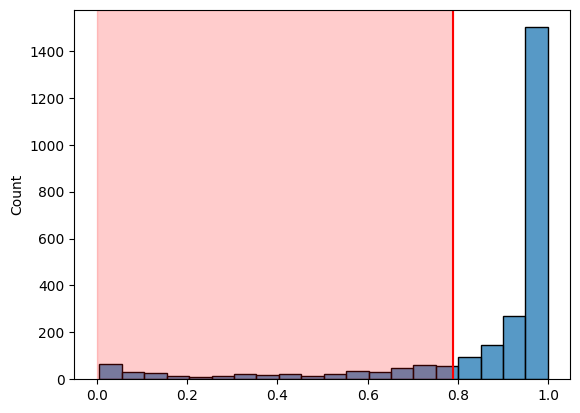

In [38]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas, bins=20)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

In [35]:
# formality, informal to formal
config = {'task': 'formality',
          'source_data': '/data/hyeryung/mucoco/data/formality/GYAFC_Corpus/Entertainment_Music/test/informal',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.74],
          'target_label_ids': [1],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

1416 out of 1416 samples are not satisfied


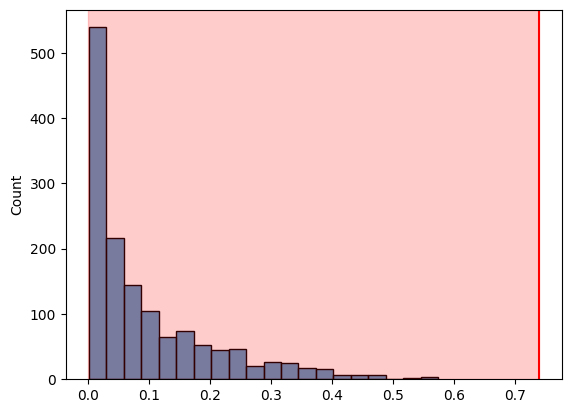

In [36]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas, bins=20)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

In [23]:
# formality, formal to informal
config = {'task': 'formality',
          'source_data': '/data/hyeryung/mucoco/data/formality/GYAFC_Corpus/Entertainment_Music/test/formal',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.88],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

1052 out of 1082 samples are not satisfied


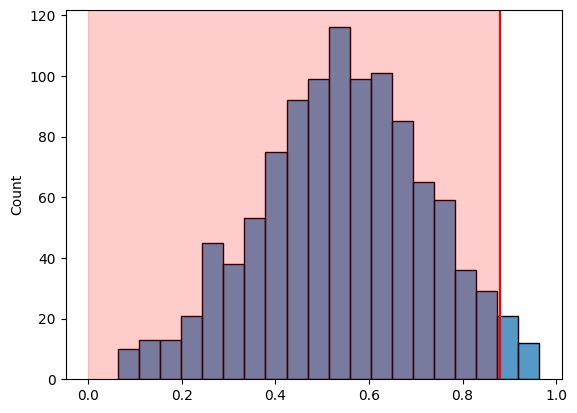

In [28]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

In [30]:
# sentiment, positive
config = {'task': 'sentiment',
          'source_data': '/data/hyeryung/mucoco/new_module/data/sentiment/dev_set.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.97],
          'target_label_ids': [1],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

778 out of 900 samples are not satisfied


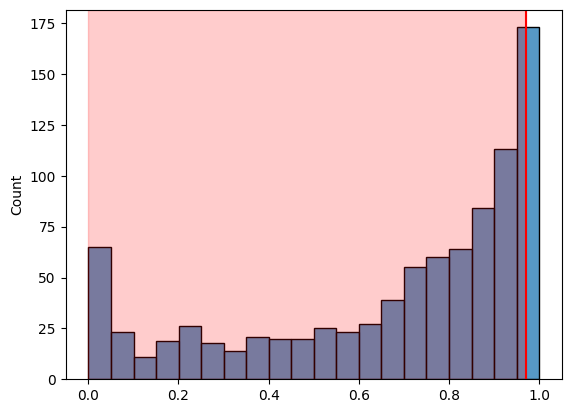

In [32]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas, bins=20)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

In [33]:
# sentiment, negative
config = {'task': 'sentiment',
          'source_data': '/data/hyeryung/mucoco/new_module/data/sentiment/dev_set.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.92],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

827 out of 900 samples are not satisfied


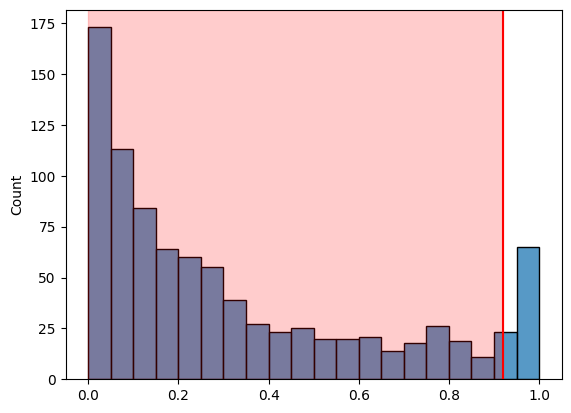

In [34]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas, bins=20)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

In [45]:
# logical consistency, consistent
config = {'task': 'nli',
          'source_data': '/data/hyeryung/mucoco/new_module/data/logical-consistency/anli-r2-test_prompt_4.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/nli/roberta_large_snli_mnli_anli_train_dev_with_finegrained_finegrained_labels_cross_entropy_n_a/zgs9e2sr/'],
          'model_types': ['EncoderModel'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.99],
          'target_label_ids': [1],
          'losses': ["classification"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats, losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


3105 out of 10000 samples are not satisfied


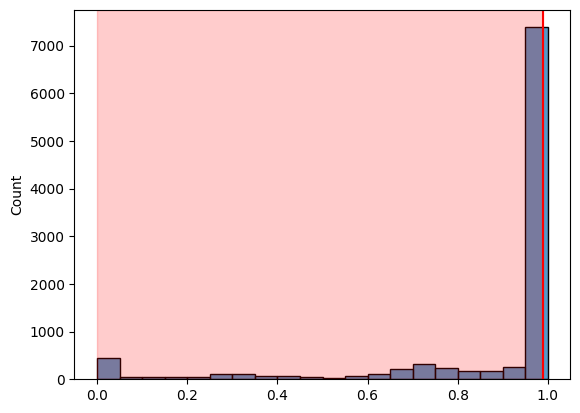

In [46]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas, bins=20)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

In [ ]:
# logical consistency, consistent (using classifier) -- 사용하지 않기로 
config = {'task': 'nli',
          'source_data': '/data/hyeryung/mucoco/new_module/data/logical-consistency/anli-r2-test_prompt_4.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/nli/roberta_large_snli_mnli_anli_train_dev_with_finegrained_binary_labels_binary_cross_entropy_n_a/1731247443/'],
          'model_types': ['EncoderModel'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.99],
          'target_label_ids': [1],
          'losses': ["classification"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats, losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


4523 out of 10000 samples are not satisfied


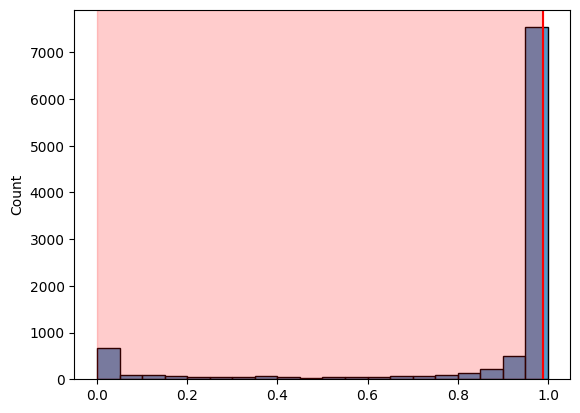

In [5]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas, bins=20)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

# Save below-threshold test set

## toxicity, nontoxic

#### gpt2-large

In [94]:
config = {'task': 'toxicity',
          'source_data': '/data/hyeryung/mucoco/new_module/data/toxicity-avoidance/testset_gpt2_2500.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.79],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats, losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

468 out of 2500 samples are not satisfied


In [95]:
# save index
nonsat_index = np.where(~np.array(allsats))[0].tolist()
with open('/data/hyeryung/mucoco/new_module/data/toxicity-avoidance/testset_gpt2_2500_below_nontoxic_threshold_index.txt', 'w') as f:
    f.writelines(' '.join([str(x) for x in nonsat_index]))
    f.write('\n')

In [ ]:
# read source data
data = pd.read_json(config['source_data'], lines=True)
# unravel
data = data.explode('generations').reset_index().rename(columns={'index':'prompt_idx'})
# select those below threshold
data = data.loc[~np.array(allsats),:].copy()
# ravel back data
data['generations'] = data['generations'].apply(lambda x: [x])
generations = data.groupby('prompt_idx')['generations'].sum().reset_index()
prompts = data[['prompt_idx','prompt']].drop_duplicates(subset='prompt_idx')
filtered_data = pd.merge(prompts, generations, on='prompt_idx')
filtered_data = filtered_data.sort_values(by='prompt_idx').drop(columns='prompt_idx')
# save data
filtered_data.to_json('/data/hyeryung/mucoco/new_module/data/toxicity-avoidance/testset_gpt2_2500_below_nontoxic_threshold_468.jsonl', orient='records', lines=True)

#### gpt3.5

In [ ]:
source_data_path = '/data/hyeryung/mucoco/new_module/llm_experiments/generate_with_llm/baselm_gens/gpt-3.5-turbo-0125/nontoxic/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_150.jsonl'

In [ ]:
config = {'task': 'toxicity',
          'source_data': source_data_path,
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.95],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats, losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")
cnt = sum(~np.array(allsats))

332 out of 2500 samples are not satisfied


In [ ]:
# save index
nonsat_index = np.where(~np.array(allsats))[0].tolist()
with open(source_data_path.split('.jsonl')[0] + '_below_nontoxic_threshold_0_95_332_index.txt', 'w') as f:
    f.writelines(' '.join([str(x) for x in nonsat_index]))
    f.write('\n')

In [ ]:
# read source data
data = pd.read_json(config['source_data'], lines=True)
# unravel
data = data.explode('generations').reset_index().rename(columns={'index':'prompt_idx'})
# select those below threshold
data = data.loc[~np.array(allsats),:].copy()
# ravel back data
data['generations'] = data['generations'].apply(lambda x: [x])
generations = data.groupby('prompt_idx')['generations'].sum().reset_index()
prompts = data[['prompt_idx','prompt']].drop_duplicates(subset='prompt_idx')
filtered_data = pd.merge(prompts, generations, on='prompt_idx')
filtered_data = filtered_data.sort_values(by='prompt_idx').drop(columns='prompt_idx')
# save data
filtered_data.to_json(source_data_path.split('.jsonl')[0] + '_below_nontoxic_threshold_0_95_332.jsonl', orient='records', lines=True)

#### prompt failure (nontoxic+neg)

In [ ]:
source_data_path = '/data/hyeryung/mucoco/new_module/llm_experiments/generate_with_llm/baselm_gens/gpt-3.5-turbo-0125/multi/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_nontoxic_neg_150.jsonl'
min_epsilon = 0.95

In [ ]:
config = {'task': 'toxicity',
          'source_data': source_data_path,
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [min_epsilon],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats, losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")
cnt = sum(~np.array(allsats))

1082 out of 2500 samples are not satisfied


In [ ]:
# save index
nonsat_index = np.where(~np.array(allsats))[0].tolist()
with open(source_data_path.split('.jsonl')[0] + f"_below_nontoxic_threshold_{str(min_epsilon).replace('.','_')}_{cnt}_index.txt", 'w') as f:
    f.writelines(' '.join([str(x) for x in nonsat_index]))
    f.write('\n')

In [ ]:
# read source data
data = pd.read_json(config['source_data'], lines=True)
# unravel
data = data.explode('generations').reset_index().rename(columns={'index':'prompt_idx'})
# select those below threshold
data = data.loc[~np.array(allsats),:].copy()
# ravel back data
data['generations'] = data['generations'].apply(lambda x: [x])
generations = data.groupby('prompt_idx')['generations'].sum().reset_index()
prompts = data[['prompt_idx','prompt']].drop_duplicates(subset='prompt_idx')
filtered_data = pd.merge(prompts, generations, on='prompt_idx')
filtered_data = filtered_data.sort_values(by='prompt_idx').drop(columns='prompt_idx')
# save data
filtered_data.to_json(source_data_path.split('.jsonl')[0] + f"_below_nontoxic_threshold_{str(min_epsilon).replace('.','_')}_{cnt}.jsonl", orient='records', lines=True)

#### prompt failure (nontoxic+neg+informal)

In [ ]:
source_data_path = '/data/hyeryung/mucoco/new_module/llm_experiments/generate_with_llm/baselm_gens/gpt-3.5-turbo-0125/multi/gpt-3.5-turbo-0125_realtoxicityprompts_0shot_nontoxic_neg_informal_150.jsonl'
min_epsilon = 0.95

In [ ]:
config = {'task': 'toxicity',
          'source_data': source_data_path,
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [min_epsilon],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats, losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")
cnt = sum(~np.array(allsats))

2056 out of 2500 samples are not satisfied


In [ ]:
# save index
nonsat_index = np.where(~np.array(allsats))[0].tolist()
with open(source_data_path.split('.jsonl')[0] + f"_below_nontoxic_threshold_{str(min_epsilon).replace('.','_')}_{cnt}_index.txt", 'w') as f:
    f.writelines(' '.join([str(x) for x in nonsat_index]))
    f.write('\n')

In [ ]:
# read source data
data = pd.read_json(config['source_data'], lines=True)
# unravel
data = data.explode('generations').reset_index().rename(columns={'index':'prompt_idx'})
# select those below threshold
data = data.loc[~np.array(allsats),:].copy()
# ravel back data
data['generations'] = data['generations'].apply(lambda x: [x])
generations = data.groupby('prompt_idx')['generations'].sum().reset_index()
prompts = data[['prompt_idx','prompt']].drop_duplicates(subset='prompt_idx')
filtered_data = pd.merge(prompts, generations, on='prompt_idx')
filtered_data = filtered_data.sort_values(by='prompt_idx').drop(columns='prompt_idx')
# save data
filtered_data.to_json(source_data_path.split('.jsonl')[0] + f"_below_nontoxic_threshold_{str(min_epsilon).replace('.','_')}_{cnt}.jsonl", orient='records', lines=True)

## sentiment, positive

In [96]:
# sentiment, positive
config = {'task': 'sentiment',
          'source_data': '/data/hyeryung/mucoco/new_module/data/sentiment/dev_set.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.97],
          'target_label_ids': [1],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

778 out of 900 samples are not satisfied


In [97]:
# save index
nonsat_index = np.where(~np.array(allsats))[0].tolist()
print(len(nonsat_index))
with open('/data/hyeryung/mucoco/new_module/data/sentiment/dev_set_below_positive_threshold_index.jsonl', 'w') as f:
    f.writelines(' '.join([str(x) for x in nonsat_index]))
    f.write('\n')

778


In [71]:
# read source data
data = pd.read_json(config['source_data'], lines=True)

# unravel
data = data.explode('generations').reset_index().rename(columns={'index':'prompt_idx'})

# select those below threshold
data = data.loc[~np.array(allsats),:].copy()
print(data.shape)

# ravel back data
data['generations'] = data['generations'].apply(lambda x: [x])
generations = data.groupby('prompt_idx')['generations'].sum().reset_index()
prompts = data[['prompt_idx','prompt']].drop_duplicates(subset='prompt_idx')
filtered_data = pd.merge(prompts, generations, on='prompt_idx')
filtered_data = filtered_data.sort_values(by='prompt_idx').drop(columns='prompt_idx')

# save data
filtered_data.to_json('/data/hyeryung/mucoco/new_module/data/sentiment/dev_set_below_positive_threshold_778.jsonl', orient='records', lines=True)

(778, 4)


## sentiment, negative

In [98]:
# sentiment, negative
config = {'task': 'sentiment',
          'source_data': '/data/hyeryung/mucoco/new_module/data/sentiment/dev_set.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.92],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

827 out of 900 samples are not satisfied


In [99]:
# save index
nonsat_index = np.where(~np.array(allsats))[0].tolist()
print(len(nonsat_index))
with open('/data/hyeryung/mucoco/new_module/data/sentiment/dev_set_below_negative_threshold_index.jsonl', 'w') as f:
    f.writelines(' '.join([str(x) for x in nonsat_index]))
    f.write('\n')

827


In [73]:
# read source data
data = pd.read_json(config['source_data'], lines=True)

# unravel
data = data.explode('generations').reset_index().rename(columns={'index':'prompt_idx'})

# select those below threshold
data = data.loc[~np.array(allsats),:].copy()
print(data.shape)

# ravel back data
data['generations'] = data['generations'].apply(lambda x: [x])
generations = data.groupby('prompt_idx')['generations'].sum().reset_index()
prompts = data[['prompt_idx','prompt']].drop_duplicates(subset='prompt_idx')
filtered_data = pd.merge(prompts, generations, on='prompt_idx')
filtered_data = filtered_data.sort_values(by='prompt_idx').drop(columns='prompt_idx')

# save data
filtered_data.to_json('/data/hyeryung/mucoco/new_module/data/sentiment/dev_set_below_negative_threshold_827.jsonl', orient='records', lines=True)

(827, 4)


## logical consistency, consistent

In [52]:
# logical consistency, consistent
config = {'task': 'nli',
          'source_data': '/data/hyeryung/mucoco/new_module/data/logical-consistency/anli-r2-test_prompt_4.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/nli/roberta_large_snli_mnli_anli_train_dev_with_finegrained_finegrained_labels_cross_entropy_n_a/zgs9e2sr/'],
          'model_types': ['EncoderModel'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.99],
          'target_label_ids': [1],
          'losses': ["classification"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats, losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


3105 out of 10000 samples are not satisfied


In [53]:
# save index
nonsat_index = np.where(~np.array(allsats))[0].tolist()
print(len(nonsat_index))
with open('/data/hyeryung/mucoco/new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_index.jsonl', 'w') as f:
    f.writelines(' '.join([str(x) for x in nonsat_index]))
    f.write('\n')

3105


In [54]:
# read source data
data = pd.read_json(config['source_data'], lines=True)

# unravel
data = data.explode('generations').reset_index().rename(columns={'index':'prompt_idx'})

# select those below threshold
data = data.loc[~np.array(allsats),:].copy()
print(data.shape)

# ravel back data
data['generations'] = data['generations'].apply(lambda x: [x])
generations = data.groupby('prompt_idx')['generations'].sum().reset_index()
prompts = data[['prompt_idx','prompt']].drop_duplicates(subset='prompt_idx')
filtered_data = pd.merge(prompts, generations, on='prompt_idx')
filtered_data = filtered_data.sort_values(by='prompt_idx').drop(columns='prompt_idx')

# save data
filtered_data.to_json('/data/hyeryung/mucoco/new_module/data/logical-consistency/anli-r2-test_prompt_4_below_consistent_threshold_3105.jsonl', orient='records', lines=True)

(3105, 3)
